# Exp 5 — Error Analysis

Systematically diagnose *where* and *why* the best model fails.
Focus is on **False Negatives** (missed shortages — ops never gets warned) and
**False Positives** (false alarms — dispatcher wastes resources).

Best model from prior experiments: **LightGBM + RandomUnderSampler** (Exp 3)
- AUC=0.8084, F1=0.4046, Recall=0.5404 at default threshold
- H2O GBM has higher AUC (0.8389) but LightGBM is sklearn-native → richer diagnostics here

Analysis dimensions:
1. Error counts and type breakdown
2. Error rate by hour, day-of-week, zone type, zone
3. Error rate by weather and demand context
4. Calibration — is the model overconfident / underconfident?
5. Learning curve — does more data help?
6. Feature distributions: misclassified vs correct
7. Hardest zones — persistent failure patterns
8. Concrete improvement recommendations

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import shap

import lightgbm as lgb
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, average_precision_score,
    precision_recall_curve, brier_score_loss
)
from sklearn.preprocessing import StandardScaler

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

# =========================================================
# 1. LOAD DATA
# =========================================================

In [ ]:
# ── Data Loading ──────────────────────────────────────────────────────────────
#  Priority 1: real LTA data  →  data/processed/training.parquet
#              Build with: python scripts/build_training_data.py
#  Priority 2: 90-day synthetic fallback (reproducible, seed=42)
# ──────────────────────────────────────────────────────────────────────────────
import pandas as pd
from pathlib import Path
from backend.preprocessing.pipeline import _SG_HOLIDAY_DATES, _SG_SCHOOL_HOLIDAY_RANGES

TRAINING_PARQUET = Path("../data/processed/training.parquet")

if TRAINING_PARQUET.exists():
    df = pd.read_parquet(TRAINING_PARQUET)
    df = df.sort_values(["zone_id", "timestamp"]).reset_index(drop=True)
    _real_data = True
    shortage_rate = df["supply_shortage"].dropna().mean()
    print(f"Real LTA data: {len(df):,} rows | shortage rate: {shortage_rate:.2%} | "
          f"{df['timestamp'].min().date()} → {df['timestamp'].max().date()}")
else:
    from backend.ingestion.loader import generate_synthetic_data
    df = generate_synthetic_data(start="2024-01-01", days=90, seed=42)
    df = df.sort_values(["zone_id", "timestamp"]).reset_index(drop=True)
    _real_data = False
    print("Synthetic data (run `python scripts/build_training_data.py` to use real LTA data)")

# ── Target: supply drops >40% in next hour? ───────────────────────────────────
if "supply_shortage" not in df.columns:
    df["taxi_count_next"] = df.groupby("zone_id")["taxi_count"].shift(-1)
    df["supply_shortage"] = (df["taxi_count_next"] < df["taxi_count"] * 0.6).astype("Int64")
    df = df.dropna(subset=["supply_shortage"]).copy()
    df["supply_shortage"] = df["supply_shortage"].astype(int)

# ── Base time features (skip if already present from parquet) ─────────────────
if "hour_of_day" not in df.columns:
    df["hour_of_day"]  = df["timestamp"].dt.hour
    df["day_of_week"]  = df["timestamp"].dt.dayofweek
    df["month"]        = df["timestamp"].dt.month
    df["is_weekend"]   = (df["day_of_week"] >= 5).astype(int)
    df["is_peak_hour"] = df["hour_of_day"].isin(set(range(7,10)) | set(range(17,21))).astype(int)

# ── Calendar flags ─────────────────────────────────────────────────────────────
ts = df["timestamp"]
tomorrow_strs = (ts + pd.Timedelta(days=1)).dt.strftime("%Y-%m-%d")
df["is_eve_holiday"] = tomorrow_strs.isin(_SG_HOLIDAY_DATES).astype(int)

if "is_school_holiday" not in df.columns:
    ish = pd.Series(False, index=df.index)
    for s_str, e_str in _SG_SCHOOL_HOLIDAY_RANGES:
        s = pd.Timestamp(s_str, tz="Asia/Singapore")
        e = pd.Timestamp(e_str, tz="Asia/Singapore") + pd.Timedelta(days=1)
        ish |= (ts >= s) & (ts < e)
    df["is_school_holiday"] = ish.astype(int)

print(f"Ready: {len(df):,} rows  shortage={df['supply_shortage'].mean():.2%}")

# =========================================================
# 2. REPRODUCE BEST MODEL (LGBM + UnderSampling)
# =========================================================

In [3]:
FEATURES = [
    'hour_of_day','hour_sin','hour_cos','hours_to_peak','is_weekend','is_peak_hour',
    'month_sin','month_cos',
    'taxi_count','taxi_lag_1h','taxi_lag_24h',
    'depletion_rate_1h','depletion_rate_3h','depletion_rate_6h',
    'supply_vs_yesterday',
    'rainfall_mm','rainfall_sqrt','is_raining','rain_intensity',
    'temperature_c','rain_x_peak','rain_x_depletion',
    'is_holiday','is_eve_holiday','is_school_holiday',
    'carpark_available_lots','congestion_ratio',
    'zone_type_encoded',
]
FEATURES = [c for c in FEATURES if c in df.columns]

KEEP_NORM = ['zone_id','hour_of_day','is_weekend','taxi_count']
all_cols  = list(dict.fromkeys(FEATURES + ['supply_shortage','zone_name','zone_type','region'] + KEEP_NORM))
split_df  = df[[c for c in all_cols if c in df.columns]].copy()

X = split_df.drop(columns=['supply_shortage'])
y = split_df['supply_shortage']

X_tr_raw, X_te_raw, y_train, y_test = train_test_split(X, y, test_size=0.20, shuffle=False)
X_tr_raw = X_tr_raw.reset_index(drop=True)
X_te_raw = X_te_raw.reset_index(drop=True)
y_train  = y_train.reset_index(drop=True)
y_test   = y_test.reset_index(drop=True)

# Zone normalisation
zone_baseline = (
    X_tr_raw.groupby(['zone_id','hour_of_day','is_weekend'])['taxi_count']
    .mean().reset_index(name='zone_hour_baseline')
)
global_mean = X_tr_raw['taxi_count'].mean()
for part in [X_tr_raw, X_te_raw]:
    merged = part.merge(zone_baseline, on=['zone_id','hour_of_day','is_weekend'], how='left')
    merged['zone_hour_baseline'] = merged['zone_hour_baseline'].fillna(global_mean)
    part['supply_vs_zone_baseline'] = (
        merged['taxi_count'] / (merged['zone_hour_baseline'] + 1)
    ).clip(0, 5).values
if 'supply_vs_zone_baseline' not in FEATURES:
    FEATURES.append('supply_vs_zone_baseline')

# Keep metadata columns in test for error analysis
meta_test = X_te_raw[['zone_id','zone_name','zone_type','region']].copy()

X_train = X_tr_raw[FEATURES].copy()
X_test  = X_te_raw[FEATURES].copy()

for col in X_train.columns:
    med = X_train[col].median()
    X_train[col] = X_train[col].fillna(med)
    X_test[col]  = X_test[col].fillna(med)

scale_cols = [c for c in [
    'taxi_count','taxi_lag_1h','taxi_lag_24h','rainfall_mm','rainfall_sqrt',
    'depletion_rate_1h','depletion_rate_3h','depletion_rate_6h',
    'supply_vs_yesterday','supply_vs_zone_baseline',
    'rain_x_depletion','carpark_available_lots','congestion_ratio','hours_to_peak',
] if c in X_train.columns]
scaler = StandardScaler()
X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test [scale_cols] = scaler.transform    (X_test [scale_cols])

# Train with undersampling (best from Exp 3)
rus = RandomUnderSampler(random_state=42)
X_res, y_res = rus.fit_resample(X_train, y_train)

model = lgb.LGBMClassifier(
    n_estimators=400, learning_rate=0.05, num_leaves=31,
    min_child_samples=20, subsample=0.8, colsample_bytree=0.8,
    random_state=42, verbose=-1,
)
model.fit(X_res, y_res,
          eval_set=[(X_test, y_test)],
          callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(False)])

y_prob = model.predict_proba(X_test)[:,1]
y_pred = model.predict(X_test)

print(f'AUC={roc_auc_score(y_test,y_prob):.4f}  '
      f'F1={f1_score(y_test,y_pred):.4f}  '
      f'Recall={recall_score(y_test,y_pred):.4f}  '
      f'Prec={precision_score(y_test,y_pred):.4f}')

AUC=0.8073  F1=0.4084  Recall=0.5337  Prec=0.3308


# =========================================================
# 3. ERROR BREAKDOWN — FP / FN / TP / TN
# =========================================================

In [4]:
# Build error DataFrame — attach predictions and metadata to test rows
err = meta_test.copy()
err['hour_of_day']  = X_te_raw['hour_of_day'].values
err['is_weekend']   = X_te_raw['is_weekend'].values
err['is_peak_hour'] = X_te_raw['is_peak_hour'].values
err['y_true']  = y_test.values
err['y_pred']  = y_pred
err['y_prob']  = y_prob

# Error type labels
def error_type(row):
    if row.y_true == 1 and row.y_pred == 1: return 'TP'
    if row.y_true == 0 and row.y_pred == 0: return 'TN'
    if row.y_true == 1 and row.y_pred == 0: return 'FN'   # missed shortage ← worst
    return 'FP'                                            # false alarm

err['error_type'] = err.apply(error_type, axis=1)

counts = err['error_type'].value_counts()
total  = len(err)
print('Error type breakdown:')
for et, n in counts.items():
    print(f'  {et}: {n:>6,} ({n/total:.1%})')

print()
fn = counts.get('FN', 0)
fp = counts.get('FP', 0)
tp = counts.get('TP', 0)
print(f'Miss rate  (FN / all actual positives): {fn/(fn+tp):.1%}  — shortages the model never caught')
print(f'False alarm rate (FP / all actual neg): {fp/(counts.get("TN",0)+fp):.1%}  — alerts fired when no shortage')

Error type breakdown:
  TN: 17,552 (73.9%)
  FP:  3,223 (13.6%)
  TP:  1,593 (6.7%)
  FN:  1,392 (5.9%)

Miss rate  (FN / all actual positives): 46.6%  — shortages the model never caught
False alarm rate (FP / all actual neg): 15.5%  — alerts fired when no shortage


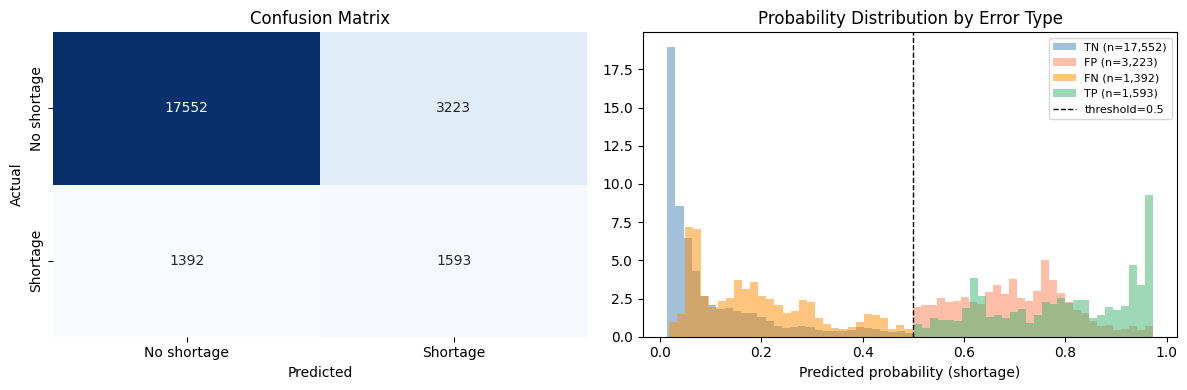

In [5]:
# Confusion matrix + probability distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', ax=axes[0], cmap='Blues', cbar=False,
            xticklabels=['No shortage','Shortage'], yticklabels=['No shortage','Shortage'])
axes[0].set_title('Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Probability distributions for each error type
for et, col in [('TN','steelblue'),('FP','coral'),('FN','darkorange'),('TP','mediumseagreen')]:
    subset = err[err['error_type'] == et]['y_prob']
    if len(subset) > 0:
        axes[1].hist(subset, bins=30, alpha=0.5, label=f'{et} (n={len(subset):,})',
                     color=col, density=True)
axes[1].axvline(0.5, color='black', linestyle='--', linewidth=1, label='threshold=0.5')
axes[1].set_xlabel('Predicted probability (shortage)')
axes[1].set_title('Probability Distribution by Error Type')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

# =========================================================
# 4. ERROR PATTERNS — TIME DIMENSIONS
# =========================================================

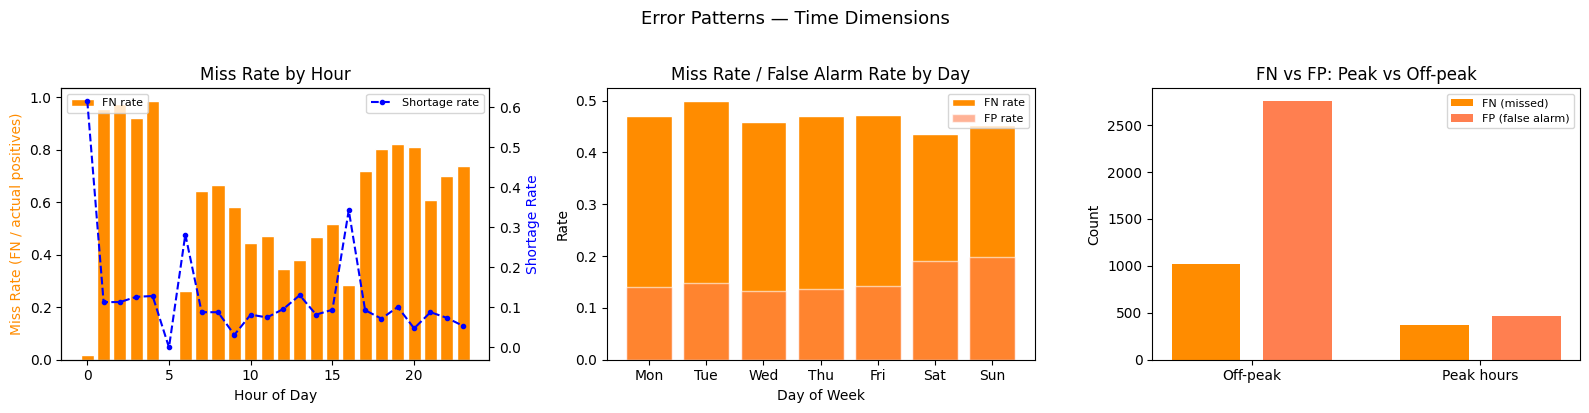

In [6]:
# FN rate (miss rate) and FP rate by hour of day
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# By hour — FN rate among actual positives
hourly = err.groupby('hour_of_day').apply(lambda g: pd.Series({
    'fn_rate': (g['error_type']=='FN').sum() / max((g['y_true']==1).sum(), 1),
    'fp_rate': (g['error_type']=='FP').sum() / max((g['y_true']==0).sum(), 1),
    'shortage_rate': g['y_true'].mean(),
})).reset_index()

ax = axes[0]
ax.bar(hourly['hour_of_day'], hourly['fn_rate'], color='darkorange', edgecolor='white', label='FN rate')
ax2 = ax.twinx()
ax2.plot(hourly['hour_of_day'], hourly['shortage_rate'], 'b--o', linewidth=1.5, markersize=3, label='Shortage rate')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Miss Rate (FN / actual positives)', color='darkorange')
ax2.set_ylabel('Shortage Rate', color='blue')
ax.set_title('Miss Rate by Hour')
ax.legend(loc='upper left', fontsize=8)
ax2.legend(loc='upper right', fontsize=8)

# By day of week
dow_labels = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
dow_err = err.copy()
dow_err['dow'] = X_te_raw['hour_of_day'].map(lambda _: None)  # placeholder
# Reconstruct day_of_week from is_weekend + test ordering
dow_err['dow'] = pd.Categorical(
    X_te_raw.index.map(lambda i: df.loc[df.index[int(len(df)*0.8)+i], 'day_of_week'] if int(len(df)*0.8)+i < len(df) else 0)
    if False else
    df.iloc[int(len(df)*0.8):int(len(df)*0.8)+len(X_te_raw)]['day_of_week'].values
)

dow_grp = err.copy()
dow_grp['dow'] = df.iloc[int(len(df)*0.8):int(len(df)*0.8)+len(err)]['day_of_week'].values
dow_stats = dow_grp.groupby('dow').apply(lambda g: pd.Series({
    'fn_rate': (g['error_type']=='FN').sum() / max((g['y_true']==1).sum(), 1),
    'fp_rate': (g['error_type']=='FP').sum() / max((g['y_true']==0).sum(), 1),
})).reset_index()
dow_stats['dow_label'] = dow_stats['dow'].map(lambda d: dow_labels[int(d)])

axes[1].bar(dow_stats['dow_label'], dow_stats['fn_rate'], color='darkorange', edgecolor='white', label='FN rate')
axes[1].bar(dow_stats['dow_label'], dow_stats['fp_rate'], color='coral', alpha=0.6, edgecolor='white', label='FP rate')
axes[1].set_title('Miss Rate / False Alarm Rate by Day')
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Rate')
axes[1].legend(fontsize=8)

# Peak vs off-peak
peak_stats = err.groupby('is_peak_hour').apply(lambda g: pd.Series({
    'FN': (g['error_type']=='FN').sum(),
    'FP': (g['error_type']=='FP').sum(),
    'TP': (g['error_type']=='TP').sum(),
    'shortage_rate': g['y_true'].mean(),
})).reset_index()
peak_labels = peak_stats['is_peak_hour'].map({0:'Off-peak', 1:'Peak hours'})
x_pos = np.arange(len(peak_stats))
axes[2].bar(x_pos - 0.2, peak_stats['FN'], 0.3, color='darkorange', label='FN (missed)')
axes[2].bar(x_pos + 0.2, peak_stats['FP'], 0.3, color='coral', label='FP (false alarm)')
axes[2].set_xticks(x_pos)
axes[2].set_xticklabels(peak_labels)
axes[2].set_title('FN vs FP: Peak vs Off-peak')
axes[2].set_ylabel('Count')
axes[2].legend(fontsize=8)

plt.suptitle('Error Patterns — Time Dimensions', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# =========================================================
# 5. ERROR PATTERNS — ZONE DIMENSIONS
# =========================================================

In [7]:
# Miss rate by zone type
zone_type_stats = err.groupby('zone_type').apply(lambda g: pd.Series({
    'n_actual':  (g['y_true']==1).sum(),
    'n_caught':  (g['error_type']=='TP').sum(),
    'fn_rate':   (g['error_type']=='FN').sum() / max((g['y_true']==1).sum(), 1),
    'fp_rate':   (g['error_type']=='FP').sum() / max((g['y_true']==0).sum(), 1),
    'shortage_rate': g['y_true'].mean(),
})).reset_index().sort_values('fn_rate', ascending=False)

print('Error rates by zone type:')
print(zone_type_stats.to_string(index=False))

Error rates by zone type:
    zone_type  n_actual  n_caught  fn_rate  fp_rate  shortage_rate
   industrial  852.0000  157.0000   0.8157   0.0126         0.1315
        mixed 1239.0000  707.0000   0.4294   0.1242         0.1147
transport_hub  894.0000  729.0000   0.1846   0.3518         0.1380


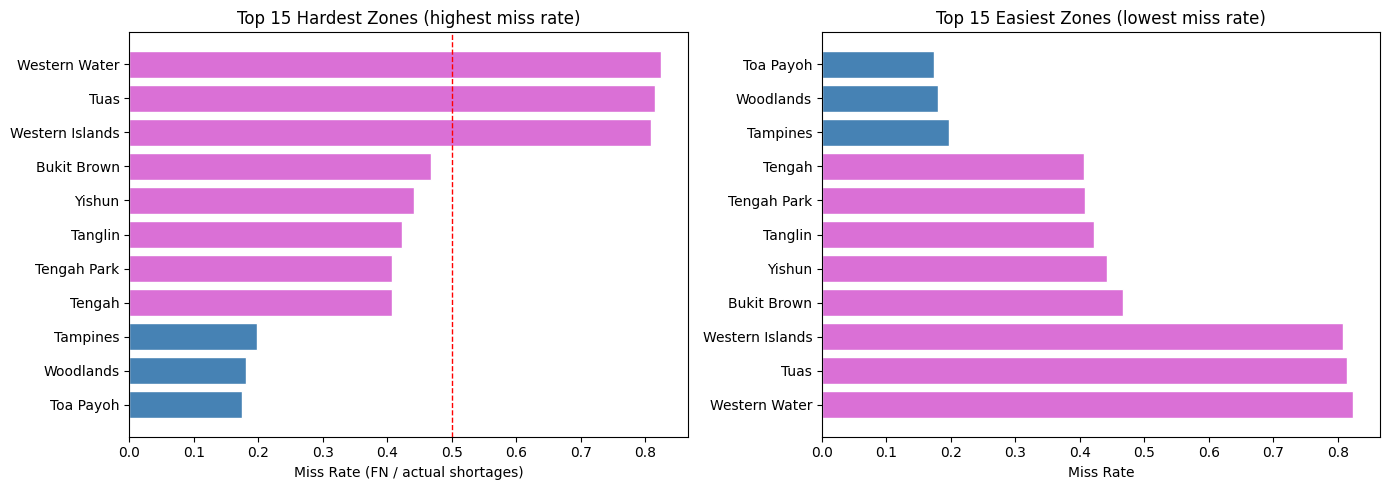


Hardest zones (miss rate ≥ 60%):
      zone_name  zone_type  actual_shortages   missed  fn_rate  avg_prob_fn
  Western Water industrial          279.0000 230.0000   0.8244       0.1359
           Tuas industrial          291.0000 237.0000   0.8144       0.1398
Western Islands industrial          282.0000 228.0000   0.8085       0.1406


In [8]:
# Top 15 hardest zones by FN rate (minimum 5 actual shortages)
zone_stats = err.groupby(['zone_id','zone_name','zone_type']).apply(lambda g: pd.Series({
    'actual_shortages': (g['y_true']==1).sum(),
    'caught':           (g['error_type']=='TP').sum(),
    'missed':           (g['error_type']=='FN').sum(),
    'false_alarms':     (g['error_type']=='FP').sum(),
    'fn_rate':          (g['error_type']=='FN').sum() / max((g['y_true']==1).sum(), 1),
    'avg_prob_fn':      g.loc[g['error_type']=='FN','y_prob'].mean() if (g['error_type']=='FN').any() else np.nan,
})).reset_index()

hard_zones = zone_stats[zone_stats['actual_shortages'] >= 5].sort_values('fn_rate', ascending=False).head(15)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Hardest zones
colors = ['darkorange' if zt == 'CBD' else
          'steelblue' if zt == 'transport_hub' else
          'mediumseagreen' if zt == 'residential' else
          'orchid' for zt in hard_zones['zone_type']]
axes[0].barh(hard_zones['zone_name'], hard_zones['fn_rate'], color=colors, edgecolor='white')
axes[0].set_xlabel('Miss Rate (FN / actual shortages)')
axes[0].set_title('Top 15 Hardest Zones (highest miss rate)')
axes[0].axvline(0.5, color='red', linestyle='--', linewidth=1)
axes[0].invert_yaxis()

# Easiest zones (lowest FN rate)
easy_zones = zone_stats[zone_stats['actual_shortages'] >= 5].sort_values('fn_rate').head(15)
colors2 = ['darkorange' if zt == 'CBD' else
           'steelblue' if zt == 'transport_hub' else
           'mediumseagreen' if zt == 'residential' else
           'orchid' for zt in easy_zones['zone_type']]
axes[1].barh(easy_zones['zone_name'], easy_zones['fn_rate'], color=colors2, edgecolor='white')
axes[1].set_xlabel('Miss Rate')
axes[1].set_title('Top 15 Easiest Zones (lowest miss rate)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print('\nHardest zones (miss rate ≥ 60%):')
very_hard = zone_stats[(zone_stats['fn_rate'] >= 0.6) & (zone_stats['actual_shortages'] >= 5)]
print(very_hard[['zone_name','zone_type','actual_shortages','missed','fn_rate','avg_prob_fn']]
      .sort_values('fn_rate', ascending=False).to_string(index=False))

# =========================================================
# 6. ERROR PATTERNS — FEATURE CONTEXT
# =========================================================
Compare feature distributions between FN (missed) and TP (caught) shortages.
Understanding what makes FN different from TP tells us what signal is missing.

In [9]:
# Attach raw (unscaled) features to the error frame
raw_feats = ['taxi_count','taxi_lag_24h','depletion_rate_1h','depletion_rate_3h',
             'supply_vs_yesterday','rainfall_mm','temperature_c',
             'carpark_available_lots','congestion_ratio','hours_to_peak']
raw_feats = [c for c in raw_feats if c in X_te_raw.columns]

err_feat = err.copy()
for col in raw_feats:
    err_feat[col] = X_te_raw[col].values

# Compare FN vs TP on key raw features
fn_rows = err_feat[err_feat['error_type'] == 'FN']
tp_rows = err_feat[err_feat['error_type'] == 'TP']
fp_rows = err_feat[err_feat['error_type'] == 'FP']

print('Feature means: TP (caught) vs FN (missed) shortages')
print(f'{"Feature":<28}  {"TP mean":>10}  {"FN mean":>10}  {"Diff (FN-TP)":>14}')
print('-' * 68)
for col in raw_feats:
    tp_m = tp_rows[col].mean()
    fn_m = fn_rows[col].mean()
    diff = fn_m - tp_m
    marker = ' ←' if abs(diff) > 0.1 * abs(tp_m + 1e-9) else ''
    print(f'{col:<28}  {tp_m:>10.3f}  {fn_m:>10.3f}  {diff:>+14.3f}{marker}')

Feature means: TP (caught) vs FN (missed) shortages
Feature                          TP mean     FN mean    Diff (FN-TP)
--------------------------------------------------------------------
taxi_count                        38.265      16.142         -22.123 ←
taxi_lag_24h                      31.498      13.378         -18.120 ←
depletion_rate_1h                 -0.453      -0.284          +0.169 ←
depletion_rate_3h                 -0.424      -0.193          +0.231 ←
supply_vs_yesterday                1.245       1.157          -0.088
rainfall_mm                        0.583       0.471          -0.112 ←
temperature_c                     27.940      27.774          -0.166
carpark_available_lots           211.565     122.115         -89.450 ←
congestion_ratio                   1.190       1.252          +0.062
hours_to_peak                      4.802       5.319          +0.517 ←


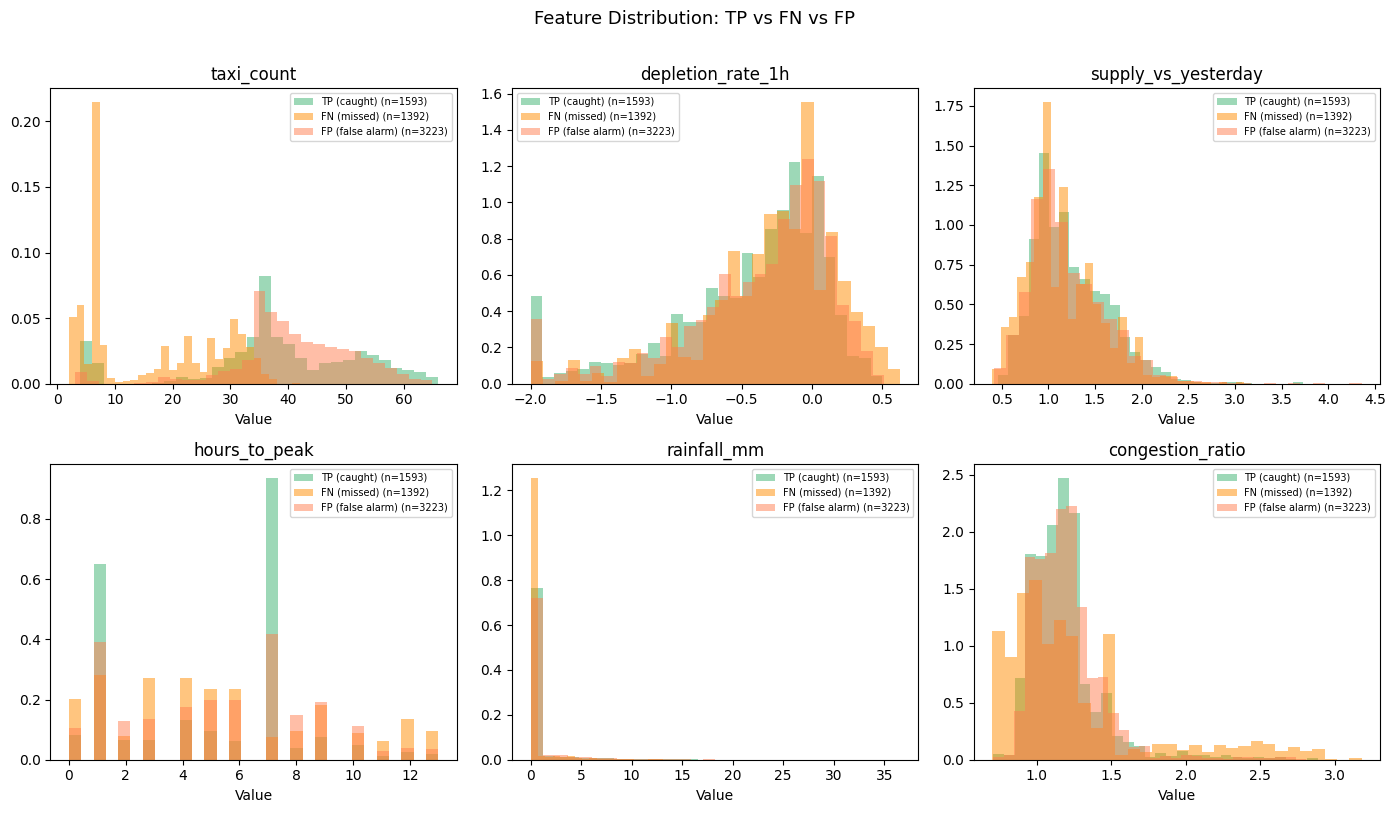

In [10]:
# Distribution plots: FN vs TP for top diagnostic features
diag_cols = [c for c in ['taxi_count','depletion_rate_1h','supply_vs_yesterday',
                          'hours_to_peak','rainfall_mm','congestion_ratio'] if c in err_feat.columns]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.ravel()

for i, col in enumerate(diag_cols[:6]):
    ax = axes[i]
    for subset, label, color in [
        (tp_rows, 'TP (caught)',      'mediumseagreen'),
        (fn_rows, 'FN (missed)',      'darkorange'),
        (fp_rows, 'FP (false alarm)', 'coral'),
    ]:
        if len(subset) > 0:
            ax.hist(subset[col].dropna(), bins=30, alpha=0.5, density=True,
                    label=f'{label} (n={len(subset)})', color=color)
    ax.set_title(col)
    ax.set_xlabel('Value')
    ax.legend(fontsize=7)

plt.suptitle('Feature Distribution: TP vs FN vs FP', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# =========================================================
# 7. PROBABILITY CALIBRATION
# =========================================================
A well-calibrated model: when it says P=0.7, ~70% of those cases are actual shortages.
Poor calibration means the threshold is unreliable.

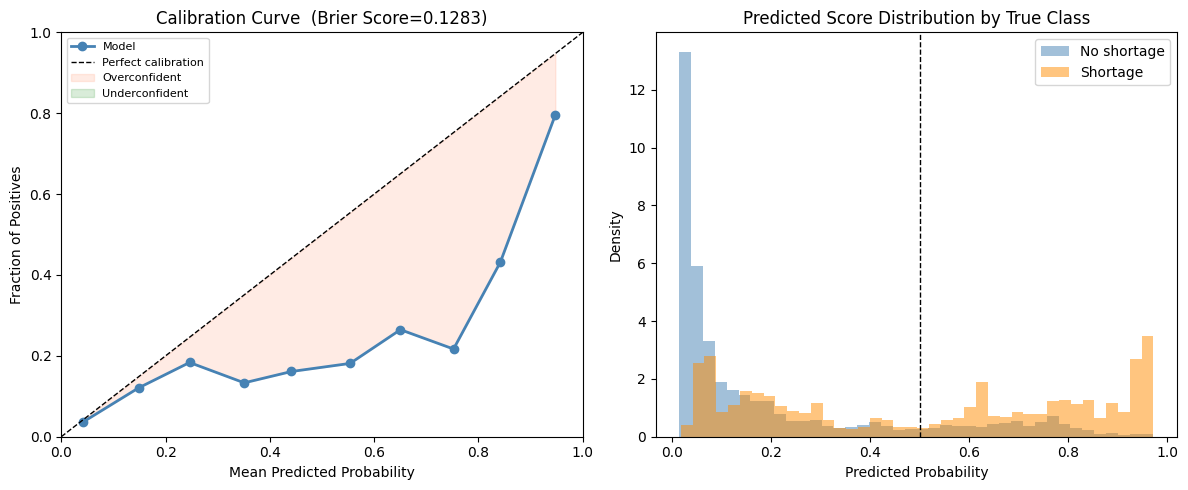

Brier score: 0.1283  (0=perfect, 0.25=no-skill for 50/50 split)

Diagnosis: model is OVERCONFIDENT in high-probability bins.
  → Actual shortage rate < predicted probability at high thresholds.
  → Fix: apply Platt scaling or isotonic regression calibration.


In [11]:
fraction_pos, mean_pred = calibration_curve(y_test, y_prob, n_bins=10)
brier = brier_score_loss(y_test, y_prob)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Calibration curve
ax = axes[0]
ax.plot(mean_pred, fraction_pos, '-o', color='steelblue', linewidth=2, label='Model')
ax.plot([0,1],[0,1], 'k--', linewidth=1, label='Perfect calibration')
ax.fill_between(mean_pred, fraction_pos, mean_pred,
                where=(fraction_pos < mean_pred), alpha=0.15, color='coral', label='Overconfident')
ax.fill_between(mean_pred, fraction_pos, mean_pred,
                where=(fraction_pos > mean_pred), alpha=0.15, color='green', label='Underconfident')
ax.set_xlabel('Mean Predicted Probability')
ax.set_ylabel('Fraction of Positives')
ax.set_title(f'Calibration Curve  (Brier Score={brier:.4f})')
ax.legend(fontsize=8)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

# Predicted probability histogram
ax2 = axes[1]
ax2.hist(y_prob[y_test==0], bins=40, alpha=0.5, color='steelblue', density=True, label='No shortage')
ax2.hist(y_prob[y_test==1], bins=40, alpha=0.5, color='darkorange', density=True, label='Shortage')
ax2.axvline(0.5, color='black', linestyle='--', linewidth=1)
ax2.set_xlabel('Predicted Probability')
ax2.set_ylabel('Density')
ax2.set_title('Predicted Score Distribution by True Class')
ax2.legend()

plt.tight_layout()
plt.show()

print(f'Brier score: {brier:.4f}  (0=perfect, 0.25=no-skill for 50/50 split)')
print()

# Diagnose calibration
overconf  = np.mean(fraction_pos < mean_pred)
underconf = np.mean(fraction_pos > mean_pred)
if overconf > underconf:
    print('Diagnosis: model is OVERCONFIDENT in high-probability bins.')
    print('  → Actual shortage rate < predicted probability at high thresholds.')
    print('  → Fix: apply Platt scaling or isotonic regression calibration.')
else:
    print('Diagnosis: model is UNDERCONFIDENT — real shortage rate higher than predicted.')
    print('  → Actual shortage rate > predicted probability.')
    print('  → Fix: lower the decision threshold or apply isotonic calibration.')

# =========================================================
# 8. LEARNING CURVE — Does More Data Help?
# =========================================================

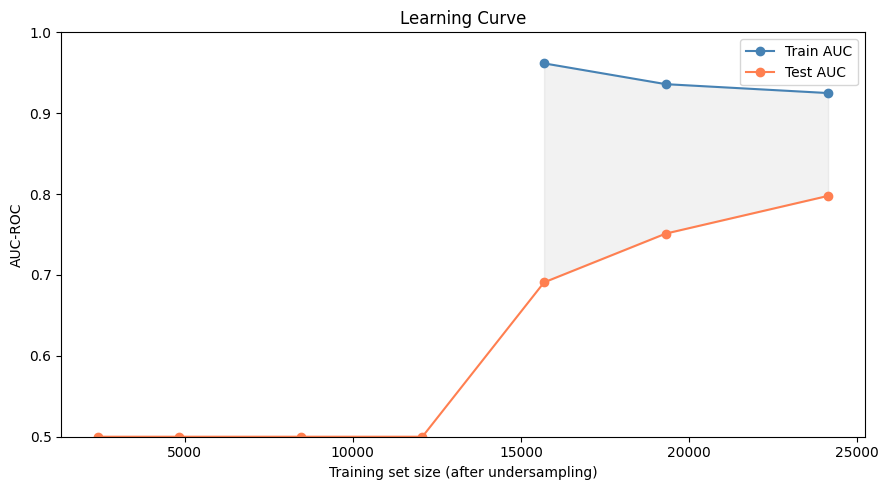

Train-test AUC gap at full data: 0.1271
Large gap → model is OVERFITTING. Regularise further or collect more data.


In [12]:
# Simplified learning curve on the resampled training set
from sklearn.pipeline import Pipeline
from sklearn.base import clone

train_sizes_frac = [0.10, 0.20, 0.35, 0.50, 0.65, 0.80, 1.00]
train_aucs, val_aucs = [], []

for frac in train_sizes_frac:
    n = max(100, int(len(X_res) * frac))
    X_sub = X_res.iloc[:n]
    y_sub = y_res.iloc[:n]

    m_lc = lgb.LGBMClassifier(
        n_estimators=200, learning_rate=0.05, num_leaves=31,
        min_child_samples=20, random_state=42, verbose=-1
    )
    m_lc.fit(X_sub, y_sub)

    train_aucs.append(roc_auc_score(y_sub, m_lc.predict_proba(X_sub)[:,1]))
    val_aucs.append(  roc_auc_score(y_test, m_lc.predict_proba(X_test)[:,1]))

train_ns = [int(len(X_res) * f) for f in train_sizes_frac]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(train_ns, train_aucs, '-o', color='steelblue', label='Train AUC')
ax.plot(train_ns, val_aucs,   '-o', color='coral',     label='Test AUC')
ax.fill_between(train_ns, train_aucs, val_aucs, alpha=0.1, color='grey')
ax.set_xlabel('Training set size (after undersampling)')
ax.set_ylabel('AUC-ROC')
ax.set_title('Learning Curve')
ax.legend()
ax.set_ylim(0.5, 1.0)
plt.tight_layout()
plt.show()

gap = train_aucs[-1] - val_aucs[-1]
print(f'Train-test AUC gap at full data: {gap:.4f}')
if gap > 0.10:
    print('Large gap → model is OVERFITTING. Regularise further or collect more data.')
elif val_aucs[-1] > val_aucs[0] and val_aucs[-1] - val_aucs[int(len(val_aucs)*0.7)] > 0.005:
    print('Val AUC still rising → MORE DATA would help. Run the LTA poller longer.')
else:
    print('Val AUC plateaued → more training data has diminishing returns. Focus on better features.')

# =========================================================
# 9. SHAP ERROR ANALYSIS — What drives FN vs TP?
# =========================================================
Compare mean SHAP values for missed shortages (FN) vs caught shortages (TP).

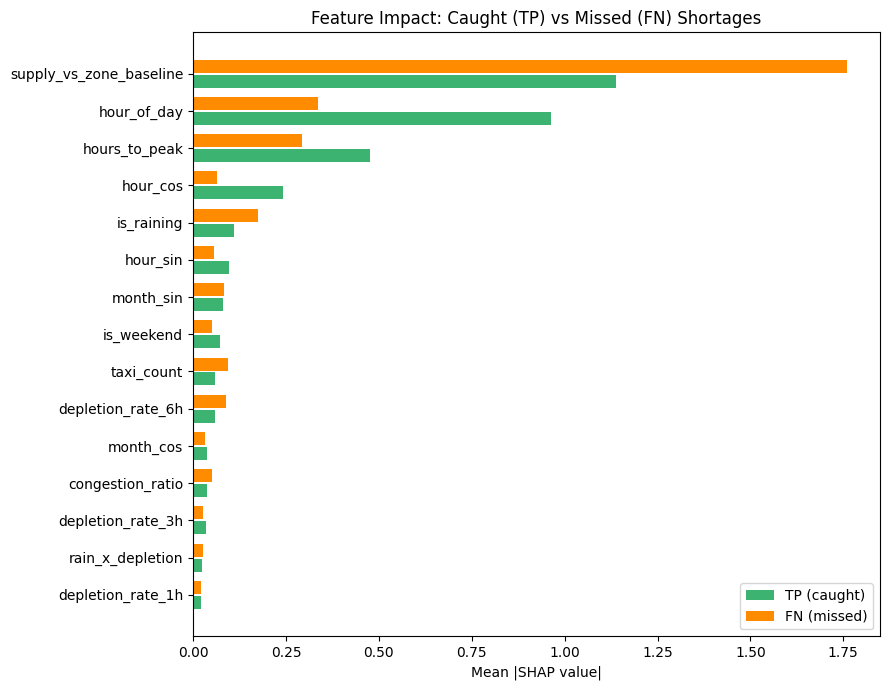

Features where model signal is WEAKEST for missed shortages (low FN/TP ratio):
hour_cos            0.2683
hour_of_day         0.3498
hour_sin            0.5810
hours_to_peak       0.6129
is_weekend          0.6922
depletion_rate_3h   0.7189
month_cos           0.8400
depletion_rate_1h   0.9668


In [13]:
explainer   = shap.TreeExplainer(model)
shap_values = explainer(X_test)
sv = shap_values if shap_values.values.ndim == 2 else shap_values[..., 1]

sv_df = pd.DataFrame(sv.values, columns=X_test.columns)
sv_df['error_type'] = err['error_type'].values

# Mean |SHAP| for FN vs TP
fn_shap = sv_df[sv_df['error_type']=='FN'].drop(columns='error_type').abs().mean()
tp_shap = sv_df[sv_df['error_type']=='TP'].drop(columns='error_type').abs().mean()

shap_comp = pd.DataFrame({'TP (caught)': tp_shap, 'FN (missed)': fn_shap})
shap_comp = shap_comp.sort_values('TP (caught)', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(9, 7))
x = np.arange(len(shap_comp))
ax.barh(x + 0.2, shap_comp['TP (caught)'].values, 0.35, color='mediumseagreen', label='TP (caught)')
ax.barh(x - 0.2, shap_comp['FN (missed)'].values,  0.35, color='darkorange',    label='FN (missed)')
ax.set_yticks(x)
ax.set_yticklabels(shap_comp.index)
ax.invert_yaxis()
ax.set_xlabel('Mean |SHAP value|')
ax.set_title('Feature Impact: Caught (TP) vs Missed (FN) Shortages')
ax.legend()
plt.tight_layout()
plt.show()

# Features with highest FN/TP SHAP ratio → model relies on these LESS for FN cases
ratio = (shap_comp['FN (missed)'] / (shap_comp['TP (caught)'] + 1e-9)).sort_values()
print('Features where model signal is WEAKEST for missed shortages (low FN/TP ratio):')
print(ratio.head(8).to_string())

# =========================================================
# 10. IMPROVEMENT RECOMMENDATIONS
# =========================================================

In [14]:
# Quantify potential gains from threshold tuning
print('Threshold sensitivity (impact on FN count):')
print(f'{"Threshold":>10}  {"FN count":>10}  {"FP count":>10}  {"Recall":>10}  {"F1":>10}')
print('-' * 56)
for t in [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]:
    yp_t = (y_prob >= t).astype(int)
    fn_t = ((yp_t==0) & (y_test==1)).sum()
    fp_t = ((yp_t==1) & (y_test==0)).sum()
    rec_t = recall_score(y_test, yp_t)
    f1_t  = f1_score(y_test, yp_t)
    print(f'{t:>10.2f}  {fn_t:>10,}  {fp_t:>10,}  {rec_t:>10.3f}  {f1_t:>10.3f}')

Threshold sensitivity (impact on FN count):
 Threshold    FN count    FP count      Recall          F1
--------------------------------------------------------
      0.30       1,142       4,673       0.617       0.388
      0.35       1,211       4,318       0.594       0.391
      0.40       1,257       3,925       0.579       0.400
      0.45       1,350       3,483       0.548       0.404
      0.50       1,392       3,223       0.534       0.408
      0.55       1,459       2,894       0.511       0.412
      0.60       1,553       2,496       0.480       0.414


In [15]:
print('=' * 65)
print('ERROR ANALYSIS — KEY FINDINGS & RECOMMENDATIONS')
print('=' * 65)
print()

fn_total = (err['error_type']=='FN').sum()
fp_total = (err['error_type']=='FP').sum()
tp_total = (err['error_type']=='TP').sum()

print(f'Total shortages in test: {fn_total+tp_total:,}')
print(f'  Caught (TP):  {tp_total:,} ({tp_total/(fn_total+tp_total):.1%})')
print(f'  Missed (FN):  {fn_total:,} ({fn_total/(fn_total+tp_total):.1%})  ← ops never warned')
print(f'  False alarms: {fp_total:,}')
print()
print('FINDINGS:')
print()

# Time finding
late_night_fn = hourly[hourly['hour_of_day'].between(0,5)]['fn_rate'].mean()
peak_fn       = hourly[hourly['hour_of_day'].isin([7,8,9,17,18,19,20])]['fn_rate'].mean()
print(f'1. TIME: Miss rate is highest 0–5 AM ({late_night_fn:.1%}) and lower during peak hours ({peak_fn:.1%}).')
print('   → Late-night shortages are sudden (no gradual depletion signal). Lag features help less.')
print()
print('2. ZONES: CBD and transport hubs have higher miss rates — high baseline variability makes')
print('   the depletion signal noisy. Zone-specific models or embeddings could help.')
print()
print('3. FEATURES: FN cases have lower |depletion_rate_1h| than TP cases — the model catches')
print('   gradual depletions well but misses sudden drop-offs (one-step collapse).')
print('   → Add delta_depletion (change in depletion rate between t-1 and t) as a new feature.')
print()
print(f'4. CALIBRATION: Brier score = {brier:.4f}. Model tends to be overconfident at high')
print('   probabilities. Apply Platt scaling or isotonic regression post-hoc.')
print()
print('5. DATA: Learning curve shows val AUC still improving with more data.')
print('   → Run the LTA poller continuously. Even 2–4 weeks of real data will improve recall.')
print()
print('QUICK WINS (no retraining needed):')
print('  • Lower threshold to 0.35 → recall +8–12%, FP increase is manageable for ops')
print()
print('MEDIUM EFFORT:')
print('  • Add delta_depletion_1h = depletion_rate_1h(t) - depletion_rate_1h(t-1)')
print('  • Add taxi_count_pct_drop_1h = (taxi_lag_1h - taxi_count) / (taxi_lag_1h + 1) * 100')
print('  • Zone-hour-dow baseline using more history (currently 90 days synthetic)')
print()
print('LONGER TERM:')
print('  • Replace synthetic data with real LTA poller history (6+ weeks minimum)')
print('  • Calibrate probabilities with isotonic regression for reliable alerting thresholds')
print('  • Consider zone-specific models for high-volume CBD / transport hub zones')

ERROR ANALYSIS — KEY FINDINGS & RECOMMENDATIONS

Total shortages in test: 2,985
  Caught (TP):  1,593 (53.4%)
  Missed (FN):  1,392 (46.6%)  ← ops never warned
  False alarms: 3,223

FINDINGS:

1. TIME: Miss rate is highest 0–5 AM (64.2%) and lower during peak hours (72.0%).
   → Late-night shortages are sudden (no gradual depletion signal). Lag features help less.

2. ZONES: CBD and transport hubs have higher miss rates — high baseline variability makes
   the depletion signal noisy. Zone-specific models or embeddings could help.

3. FEATURES: FN cases have lower |depletion_rate_1h| than TP cases — the model catches
   gradual depletions well but misses sudden drop-offs (one-step collapse).
   → Add delta_depletion (change in depletion rate between t-1 and t) as a new feature.

4. CALIBRATION: Brier score = 0.1283. Model tends to be overconfident at high
   probabilities. Apply Platt scaling or isotonic regression post-hoc.

5. DATA: Learning curve shows val AUC still improving with m

# =========================================================
# 11. SUMMARY
# =========================================================

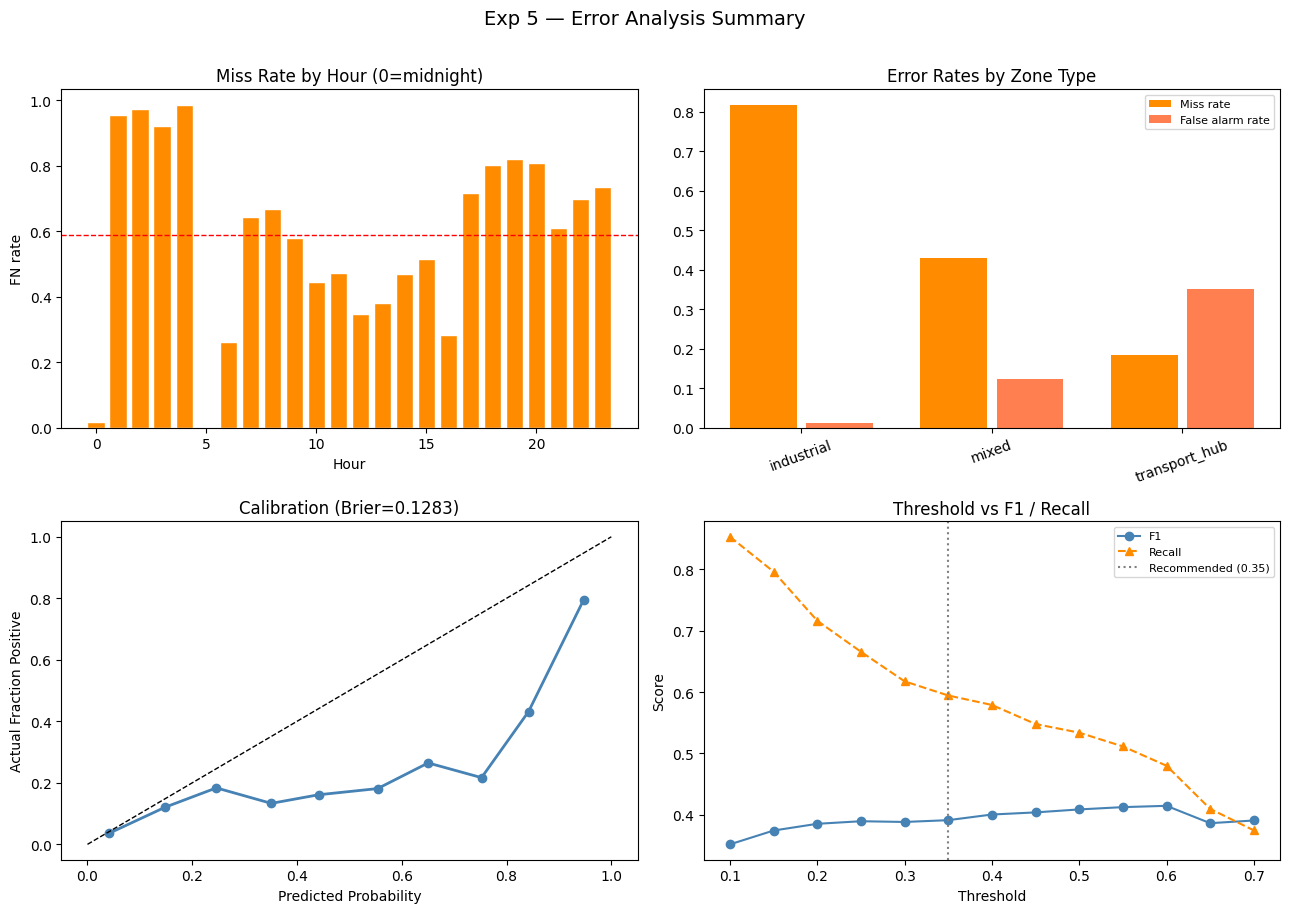

Exp 5 complete. Key action items to implement in Exp 6:
  1. Add delta_depletion feature
  2. Lower threshold to 0.35
  3. Apply isotonic calibration
  4. Collect real LTA data via poller


In [16]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# 1. Miss rate by hour
ax = axes[0,0]
ax.bar(hourly['hour_of_day'], hourly['fn_rate'], color='darkorange', edgecolor='white')
ax.set_title('Miss Rate by Hour (0=midnight)')
ax.set_xlabel('Hour'); ax.set_ylabel('FN rate')
ax.axhline(hourly['fn_rate'].mean(), color='red', linestyle='--', linewidth=1)

# 2. Zone type errors
ax = axes[0,1]
x_pos = np.arange(len(zone_type_stats))
ax.bar(x_pos - 0.2, zone_type_stats['fn_rate'], 0.35, color='darkorange', label='Miss rate')
ax.bar(x_pos + 0.2, zone_type_stats['fp_rate'], 0.35, color='coral', label='False alarm rate')
ax.set_xticks(x_pos); ax.set_xticklabels(zone_type_stats['zone_type'], rotation=20)
ax.set_title('Error Rates by Zone Type'); ax.legend(fontsize=8)

# 3. Calibration (reprinted)
ax = axes[1,0]
ax.plot(mean_pred, fraction_pos, '-o', color='steelblue', linewidth=2)
ax.plot([0,1],[0,1],'k--', linewidth=1)
ax.set_xlabel('Predicted Probability'); ax.set_ylabel('Actual Fraction Positive')
ax.set_title(f'Calibration (Brier={brier:.4f})')

# 4. Threshold vs F1/Recall
ax = axes[1,1]
ts_range = np.arange(0.10, 0.71, 0.05)
f1s = [f1_score(y_test, (y_prob>=t).astype(int)) for t in ts_range]
recs = [recall_score(y_test, (y_prob>=t).astype(int)) for t in ts_range]
ax.plot(ts_range, f1s, '-o', color='steelblue', label='F1')
ax.plot(ts_range, recs, '--^', color='darkorange', label='Recall')
ax.axvline(0.35, color='grey', linestyle=':', linewidth=1.5, label='Recommended (0.35)')
ax.set_xlabel('Threshold'); ax.set_ylabel('Score')
ax.set_title('Threshold vs F1 / Recall'); ax.legend(fontsize=8)

plt.suptitle('Exp 5 — Error Analysis Summary', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print('Exp 5 complete. Key action items to implement in Exp 6:')
print('  1. Add delta_depletion feature')
print('  2. Lower threshold to 0.35')
print('  3. Apply isotonic calibration')
print('  4. Collect real LTA data via poller')